# **Práctica 8** . Detector de Idiomas con N-gramas + Red Neuronal

## A) Retome el detector de idiomas con N-gramas, incremente los textos de referencia a al menos 500 palabras cada uno. Asigne un diccionario a cada N-grama y reimplemente el detector de idiomas. Su programa debe ser capaz de predecir incluso con palabras **QUE NO ESTÉN EN EL PATRÓN DE ENTRENAMIENTO**.

---
 A)
| # | Sección | Qué hace |
|---|---------|----------|
| 1 | **Corpus** | Textos continuos ~1500 palabras por idioma |
| 2 | **Tokenización** | Tokenizador con soporte de acentos |
| 3 | **TF-IDF manual** | Trigramas de caracteres → matriz numérica |
| 4 | **PCA** | Reducción de dimensionalidad (miles → 80 dims) |
| 5 | **Red Neuronal** | MLP densa: entrenamiento y evaluación |
| 6 | **Predicción OOV** | Pipeline completo + palabras nunca vistas |

---

### Idea de la práctica

En vez de memorizar palabras completas, el modelo aprende **patrones de trigramas de caracteres**.
Esto le permite reconocer el idioma de palabras nunca vistas (*Out Of Vocabulary*), porque sus trigramas sí fueron vistos en palabras similares del corpus.

```
"ciberseguridad"  →  trigramas: [' ci', 'cib', 'ibe', 'ber', ...]
                  →  esos trigramas son típicos del español
                  →  Red predice: ES ✓
```

---

In [3]:
# importamos las librerias necesarias
import math
import re
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

---
## 1. Corpus - textos en 3 idiomas - español, inglés y francés

Cada corpus es un **texto corrido de aprox. 1500 palabras** sobre inteligencia artificial y tecnología.

***Notitasss:***

Usamos textos continuos (no listas de palabras) porque los trigramas extraídos de texto natural son más representativos del idioma real.

Conservamos el tema del texto pq el vocabulario técnico comparte raíces grecolatinas entre idiomas (`neuro-`, `cyber-`, `-tion`), lo que hace el problema más interesante y desafiante para el modelo.

In [4]:
corpus_es = """
La inteligencia artificial es una de las ramas más fascinantes de la ciencia moderna.
Desde sus inicios en la década de los cincuenta, los investigadores han trabajado
incansablemente para desarrollar sistemas capaces de imitar el razonamiento humano.
Hoy en día, la inteligencia artificial está presente en casi todos los aspectos de
nuestra vida cotidiana: desde los teléfonos inteligentes hasta los automóviles autónomos.

El aprendizaje automático es una subdisciplina de la inteligencia artificial que permite
a las máquinas aprender a partir de los datos sin ser programadas explícitamente para
cada tarea. Los algoritmos de aprendizaje automático analizan grandes volúmenes de
información y encuentran patrones ocultos que los humanos no podrían detectar fácilmente.
Esto ha revolucionado industrias enteras como la medicina, las finanzas y el comercio
electrónico.

Las redes neuronales artificiales son modelos computacionales inspirados en el
funcionamiento del cerebro humano. Están formadas por capas de neuronas artificiales
que procesan la información de manera jerárquica. La primera capa recibe los datos de
entrada, las capas intermedias extraen características progresivamente más complejas,
y la capa final produce la predicción o clasificación deseada.

El procesamiento del lenguaje natural es otra área fundamental de la inteligencia
artificial. Se encarga de permitir que las computadoras comprendan, interpreten y
generen lenguaje humano de manera significativa. Gracias a esta tecnología, hoy existen
traductores automáticos, asistentes virtuales y sistemas de resumen de texto que
funcionan con una precisión sorprendente.

La visión por computadora permite a las máquinas interpretar y comprender el contenido
visual del mundo, como imágenes y videos. Esta tecnología se utiliza en el reconocimiento
facial, la detección de objetos, los vehículos autónomos y el diagnóstico médico por
imágenes. Los avances en redes neuronales convolucionales han sido fundamentales para
el progreso de este campo.

El análisis de sentimientos es una aplicación del procesamiento del lenguaje natural
que permite determinar la opinión o emoción expresada en un texto. Las empresas lo
utilizan para monitorear la reputación de sus marcas, analizar comentarios de clientes
y comprender las tendencias del mercado. Esta tecnología puede clasificar textos como
positivos, negativos o neutros con gran precisión.

La robótica moderna se apoya fuertemente en la inteligencia artificial para crear
máquinas capaces de interactuar con el entorno de manera autónoma. Los robots actuales
pueden realizar tareas complejas en fábricas, hospitales y hogares. La combinación de
sensores avanzados, actuadores precisos y algoritmos inteligentes permite a los robots
adaptarse a situaciones imprevistas y aprender de sus errores.

La ética en la inteligencia artificial es un tema de creciente importancia. A medida
que los sistemas de inteligencia artificial se vuelven más poderosos e influyentes,
surgen preguntas fundamentales sobre la responsabilidad, la privacidad y la equidad.
Es necesario establecer marcos regulatorios que garanticen que estas tecnologías se
desarrollen y utilicen de manera justa y transparente, respetando los derechos
fundamentales de todas las personas.

La ciencia de los datos combina estadística, matemáticas y programación para extraer
conocimiento útil de grandes conjuntos de datos. Los científicos de datos trabajan con
herramientas como Python, R y SQL para limpiar, analizar y visualizar información. Su
trabajo es fundamental para la toma de decisiones basada en evidencia en organizaciones
públicas y privadas de todo el mundo.

Los sistemas de recomendación son algoritmos que sugieren productos, contenidos o
servicios a los usuarios basándose en su historial y preferencias. Plataformas como
las de música en línea, videos y comercio electrónico utilizan estos sistemas para
personalizar la experiencia del usuario. La colaboración entre usuarios similares y el
análisis del contenido son dos enfoques principales para construir estos sistemas.

La computación en la nube ha transformado la manera en que se almacenan y procesan
los datos. Las empresas ya no necesitan invertir en costosa infraestructura física,
sino que pueden acceder a recursos computacionales a través de internet según sus
necesidades. Esta flexibilidad ha democratizado el acceso a la tecnología y ha
permitido que pequeñas empresas compitan con grandes corporaciones.

El blockchain es una tecnología de registro distribuido que permite almacenar
información de manera segura e inmutable. Originalmente desarrollado para las
criptomonedas, hoy se aplica en logística, contratos inteligentes y verificación de
identidad. Su transparencia y resistencia a la manipulación lo convierten en una
herramienta valiosa para generar confianza en entornos digitales.

La seguridad informática protege los sistemas, redes y datos de ataques maliciosos.
Con el aumento de las amenazas cibernéticas, las organizaciones invierten cada vez
más en soluciones de ciberseguridad. Las técnicas modernas incluyen el cifrado de
datos, la autenticación multifactor y el análisis de comportamiento para detectar
actividades sospechosas antes de que causen daño.

La realidad aumentada y la realidad virtual están abriendo nuevas posibilidades en
educación, entretenimiento y medicina. La realidad aumentada superpone información
digital sobre el mundo físico, mientras que la realidad virtual sumerge al usuario en
entornos completamente simulados. Estas tecnologías tienen aplicaciones prometedoras
en la capacitación de profesionales y la rehabilitación de pacientes.

El internet de las cosas conecta objetos cotidianos a internet, permitiendo que
recopilen y compartan datos. Los dispositivos inteligentes en el hogar, las ciudades
y las industrias generan enormes cantidades de información que pueden analizarse para
mejorar la eficiencia y la calidad de vida. La gestión de esta avalancha de datos
representa uno de los mayores desafíos tecnológicos actuales.
"""

corpus_en = """
Artificial intelligence is one of the most fascinating branches of modern science.
Since its beginnings in the nineteen fifties, researchers have worked tirelessly to
develop systems capable of mimicking human reasoning. Today, artificial intelligence
is present in almost every aspect of our daily lives, from smartphones to autonomous
vehicles, reshaping how we interact with technology and each other.

Machine learning is a subdiscipline of artificial intelligence that allows machines
to learn from data without being explicitly programmed for each task. Machine learning
algorithms analyze large volumes of information and find hidden patterns that humans
could not easily detect. This has revolutionized entire industries such as medicine,
finance, and electronic commerce, creating new opportunities and challenges alike.

Artificial neural networks are computational models inspired by the functioning of
the human brain. They consist of layers of artificial neurons that process information
in a hierarchical manner. The first layer receives the input data, the intermediate
layers extract progressively more complex features, and the final layer produces the
desired prediction or classification output.

Natural language processing is another fundamental area of artificial intelligence.
It enables computers to understand, interpret, and generate human language in a
meaningful way. Thanks to this technology, we now have automatic translators, virtual
assistants, and text summarization systems that work with surprising accuracy, making
communication across languages easier than ever before.

Computer vision allows machines to interpret and understand the visual content of the
world, such as images and videos. This technology is used in facial recognition,
object detection, autonomous vehicles, and medical image diagnosis. Advances in
convolutional neural networks have been fundamental to the progress of this field
over the past decade.

Sentiment analysis is an application of natural language processing that determines
the opinion or emotion expressed in a piece of text. Companies use it to monitor
their brand reputation, analyze customer feedback, and understand market trends. This
technology can classify texts as positive, negative, or neutral with great accuracy
using sophisticated machine learning models.

Modern robotics relies heavily on artificial intelligence to create machines capable
of interacting with their environment autonomously. Today's robots can perform complex
tasks in factories, hospitals, and homes. The combination of advanced sensors, precise
actuators, and intelligent algorithms allows robots to adapt to unforeseen situations
and learn continuously from their mistakes and experiences.

Ethics in artificial intelligence is a topic of growing importance in the technology
community and beyond. As artificial intelligence systems become more powerful and
influential, fundamental questions arise about responsibility, privacy, and fairness.
It is necessary to establish regulatory frameworks that ensure these technologies are
developed and used in a fair and transparent manner, respecting the fundamental rights
of all people around the world.

Data science combines statistics, mathematics, and programming to extract useful
knowledge from large datasets. Data scientists work with tools such as Python, R, and
SQL to clean, analyze, and visualize information effectively. Their work is fundamental
for evidence-based decision making in public and private organizations worldwide,
driving innovation and efficiency across all sectors.

Recommendation systems are algorithms that suggest products, content, or services
to users based on their history and preferences. Streaming platforms, online retailers,
and social networks use these systems to personalize the user experience. Collaborative
filtering between similar users and content-based analysis are two main approaches
to building effective recommendation engines.

Cloud computing has transformed the way data is stored and processed across industries.
Companies no longer need to invest in expensive physical infrastructure but can access
computational resources through the internet according to their needs. This flexibility
has democratized access to technology and allowed small businesses to compete with
large corporations on a global scale.

Blockchain is a distributed ledger technology that stores information securely and
immutably. Originally developed for cryptocurrencies, it is now applied in logistics,
smart contracts, and identity verification. Its transparency and resistance to
manipulation make it a valuable tool for generating trust in digital environments
and enabling new forms of decentralized collaboration.

Information security protects systems, networks, and data from malicious attacks.
With the increase in cyber threats, organizations are investing more and more in
cybersecurity solutions. Modern techniques include data encryption, multifactor
authentication, and behavior analysis to detect suspicious activities before they
cause significant damage to individuals or organizations.

Augmented reality and virtual reality are opening new possibilities in education,
entertainment, and medicine. Augmented reality overlays digital information onto the
physical world, while virtual reality immerses users in completely simulated
environments. These technologies have promising applications in professional training,
therapeutic treatment, and immersive entertainment experiences.

The internet of things connects everyday objects to the internet, allowing them to
collect and share data continuously. Smart devices in homes, cities, and industries
generate enormous amounts of information that can be analyzed to improve efficiency
and quality of life. Managing this avalanche of data represents one of the greatest
current technological challenges facing engineers and scientists today.
"""

corpus_fr = """
L'intelligence artificielle est l'une des branches les plus fascinantes de la science
moderne. Depuis ses débuts dans les années cinquante, les chercheurs ont travaillé
sans relâche pour développer des systèmes capables d'imiter le raisonnement humain.
Aujourd'hui, l'intelligence artificielle est présente dans presque tous les aspects
de notre vie quotidienne, des téléphones intelligents aux véhicules autonomes.

L'apprentissage automatique est une sous-discipline de l'intelligence artificielle
qui permet aux machines d'apprendre à partir des données sans être explicitement
programmées pour chaque tâche. Les algorithmes d'apprentissage automatique analysent
de grands volumes d'informations et trouvent des modèles cachés que les humains ne
pourraient pas facilement détecter. Cela a révolutionné des industries entières comme
la médecine, la finance et le commerce électronique.

Les réseaux de neurones artificiels sont des modèles informatiques inspirés du
fonctionnement du cerveau humain. Ils sont composés de couches de neurones artificiels
qui traitent l'information de manière hiérarchique. La première couche reçoit les
données d'entrée, les couches intermédiaires extraient des caractéristiques de plus
en plus complexes, et la couche finale produit la prédiction ou la classification
souhaitée par l'utilisateur.

Le traitement du langage naturel est un autre domaine fondamental de l'intelligence
artificielle. Il permet aux ordinateurs de comprendre, interpréter et générer le
langage humain de manière significative. Grâce à cette technologie, il existe
aujourd'hui des traducteurs automatiques, des assistants virtuels et des systèmes
de résumé de texte qui fonctionnent avec une précision surprenante et remarquable.

La vision par ordinateur permet aux machines d'interpréter et de comprendre le
contenu visuel du monde, comme les images et les vidéos. Cette technologie est
utilisée dans la reconnaissance faciale, la détection d'objets, les véhicules
autonomes et le diagnostic médical par imagerie. Les avancées dans les réseaux de
neurones convolutifs ont été fondamentales pour le progrès de ce domaine scientifique.

L'analyse des sentiments est une application du traitement du langage naturel qui
permet de déterminer l'opinion ou l'émotion exprimée dans un texte. Les entreprises
l'utilisent pour surveiller la réputation de leurs marques, analyser les commentaires
des clients et comprendre les tendances du marché. Cette technologie peut classer
les textes comme positifs, négatifs ou neutres avec une grande précision algorithmique.

La robotique moderne s'appuie fortement sur l'intelligence artificielle pour créer
des machines capables d'interagir avec leur environnement de manière autonome. Les
robots actuels peuvent effectuer des tâches complexes dans les usines, les hôpitaux
et les maisons. La combinaison de capteurs avancés, d'actionneurs précis et
d'algorithmes intelligents permet aux robots de s'adapter à des situations imprévues.

L'éthique dans l'intelligence artificielle est un sujet d'importance croissante.
À mesure que les systèmes d'intelligence artificielle deviennent plus puissants et
influents, des questions fondamentales se posent sur la responsabilité, la vie privée
et l'équité. Il est nécessaire d'établir des cadres réglementaires qui garantissent
que ces technologies sont développées et utilisées de manière juste et transparente,
en respectant les droits fondamentaux de toutes les personnes dans le monde entier.

La science des données combine statistiques, mathématiques et programmation pour
extraire des connaissances utiles de grands ensembles de données. Les scientifiques
des données travaillent avec des outils tels que Python, R et SQL pour nettoyer,
analyser et visualiser les informations efficacement. Leur travail est fondamental
pour la prise de décisions basée sur des preuves dans les organisations publiques
et privées du monde entier.

Les systèmes de recommandation sont des algorithmes qui suggèrent des produits,
des contenus ou des services aux utilisateurs en fonction de leur historique et
de leurs préférences. Les plateformes de streaming, les détaillants en ligne et
les réseaux sociaux utilisent ces systèmes pour personnaliser l'expérience
utilisateur. Le filtrage collaboratif et l'analyse basée sur le contenu sont
deux approches principales pour construire ces moteurs de recommandation efficaces.

L'informatique en nuage a transformé la façon dont les données sont stockées et
traitées dans les entreprises. Les entreprises n'ont plus besoin d'investir dans
une infrastructure physique coûteuse, mais peuvent accéder à des ressources
informatiques via Internet selon leurs besoins. Cette flexibilité a démocratisé
l'accès à la technologie et a permis aux petites entreprises de concurrencer les
grandes corporations mondiales.

La chaîne de blocs est une technologie de registre distribué qui permet de stocker
des informations de manière sécurisée et immuable. Développée à l'origine pour les
cryptomonnaies, elle est maintenant appliquée dans la logistique, les contrats
intelligents et la vérification d'identité. Sa transparence et sa résistance à la
manipulation en font un outil précieux pour générer de la confiance dans les
environnements numériques modernes.

La sécurité informatique protège les systèmes, les réseaux et les données contre
les attaques malveillantes. Avec l'augmentation des menaces cybernétiques, les
organisations investissent de plus en plus dans des solutions de cybersécurité.
Les techniques modernes comprennent le chiffrement des données, l'authentification
multifacteur et l'analyse comportementale pour détecter les activités suspectes
avant qu'elles ne causent des dommages importants.

La réalité augmentée et la réalité virtuelle ouvrent de nouvelles possibilités
dans l'éducation, le divertissement et la médecine. La réalité augmentée superpose
des informations numériques sur le monde physique, tandis que la réalité virtuelle
plonge l'utilisateur dans des environnements entièrement simulés. Ces technologies
ont des applications prometteuses dans la formation professionnelle et la rééducation.

L'internet des objets connecte les objets quotidiens à Internet, leur permettant
de collecter et de partager des données en permanence. Les appareils intelligents
dans les maisons, les villes et les industries génèrent d'énormes quantités
d'informations qui peuvent être analysées pour améliorer l'efficacité et la qualité
de vie. La gestion de cette avalanche de données représente l'un des plus grands
défis technologiques actuels pour les ingénieurs et les scientifiques du monde entier.
"""

---
## 2️.  Tokenización


El tokenizador de antes solo jalaba rangos ASCII `65-90` (A-Z) y `97-122` (a-z), lo que mata los caracteres acentuados.

Esto es un problema porque `é`, `ñ`, `ç`, `ü` son **marcadores discriminativos** entre idiomas:
- `cybersécurité` sin el acento → `cybersecurite` → modelo la confunde con inglés
- `sostenibilidad` → los acentos en el resto del corpus ayudan a posicionar palabras españolas

Tuvimos que **extender el tokenizador** con un `set` de caracteres extra, conservando la lógica de `ord()` de clase.

In [5]:
def tokenizador_extendido(texto):
    """
    Igual que los que hicimos antes, pero también acepta :
    á é í ó ú ü ñ à â ä è ê ë î ï ô ù û ç œ æ

    - Para letras ASCII usamos rangos ord() igual que en clase
    - Para acentuadas usamos un set de caracteres válidos adicionales
    - Todo se convierte a minúsculas para normalizar
    """
    # caracteres latinos acentuados que queremos conservar
    EXTRA = set("áéíóúüñàâäèêëîïôùûçœæÁÉÍÓÚÜÑÀÂÄÈÊËÎÏÔÙÛÇŒÆ")

    tokens   = [None] * len(texto)
    token    = ""
    contador = 0

    texto = texto + '.'   # garantiza que el último token se cierre al llegar al punto

    for letra in texto:
        # ¿es una letra ASCII normal?
        es_ascii = (ord(letra) >= 65 and ord(letra) <= 90) or \
                   (ord(letra) >= 97 and ord(letra) <= 122)
        # ¿es un carácter acentuado de nuestra lista?
        es_extra = letra in EXTRA

        if es_ascii or es_extra:
            token += letra.lower()     # acumulamos la letra en minúsculas
        else:
            if token != "":            # evita guardar tokens vacíos
                tokens[contador] = token
                contador += 1
            token = ""                 # reiniciamos para la siguiente palabra

    return tokens[0:contador]

### Palabras de refuerzo

Durante las pruebas detectamos que el modelo fallaba en palabras con raíces grecolatinas compartidas entre idiomas (`neuro-`, `cyber-`, `sosten-`), por qué al parecer **el corpus principal no tenía suficientes ejemplos** de esas raíces en cada idioma.

Así que agregamos dos tipos de refuerzo:

1. de raíces problemáticas — palabras con `neuro-`, `cyber-`, `sosten-` en los tres idiomas
2. de sufijos discriminativos — familias de palabras que terminan en sufijos únicos de cada idioma:
   - ES: `-idad`, `-ción`, `-miento`
   - EN: `-ity`, `-tion`, `-ment`
   - FR: `-ité`, `-tion`, `-ment`

El sufijo es el desempate: `cybersecuri-TY` (EN) vs `cybersécuri-TÉ` (FR).

In [6]:
# --- Refuerzo 1: raíces problemáticas en los 3 idiomas ---
palabras_extra_es = """
neurociencia neurológico neurocientífico neurona neural neuropatía
ciberseguridad ciberataque ciberespacio cibernética ciberdelito
sostenibilidad sustentable sostenible sostenimiento sustentabilidad
comunicación pronunciación generación habitación relación nación
información educación administración organización combinación
tecnología metodología terminología biología psicología
"""

palabras_extra_en = """
neuroscience neurological neuroscientist neuron neural neuropathy
cybersecurity cyberattack cyberspace cybernetics cybercrime
sustainability sustainable sustain sustenance maintaining
communication pronunciation generation relation nation
information education administration organization combination
technology methodology terminology biology psychology
"""

palabras_extra_fr = """
neuroscience neurologique neuroscientifique neurone neural neuropathie
cybersécurité cyberattaque cyberespace cybernétique cybercriminalité
durabilité soutenable durable soutien soutenabilité
communication prononciation génération relation nation
information éducation administration organisation combinaison
technologie méthodologie terminologie biologie psychologie
"""

# --- Refuerzo 2: sufijos discriminativos por idioma ---
# Estos sufijos son los que diferencian cognados entre idiomas:
# security (EN) vs sécurité (FR) vs seguridad (ES)
palabras_fr_sufijos = """
sécurité liberté égalité fraternité nationalité spécialité
originalité curiosité générosité sensibilité responsabilité
possibilité disponibilité popularité qualité quantité activité
réalité virtualité visualité complexité simplicité
productivité créativité sensitivité réactivité
chercheuse travailleuse heureuse amoureuse courageuse
chanteuse danseuse coiffeuse vendeuse directrice
chiffrement traitement établissement développement gouvernement
comportement mouvement changement investissement financement
"""

palabras_en_sufijos = """
security liberty equality fraternity nationality specialty
originality curiosity generosity sensitivity responsibility
possibility availability popularity quality quantity activity
reality virtuality complexity simplicity
productivity creativity reactivity
researcher worker happiness lover courage
singer dancer director manager investor
encryption treatment establishment development government
behavior movement change investment financing
"""

palabras_es_sufijos = """
seguridad libertad igualdad fraternidad nacionalidad especialidad
originalidad curiosidad generosidad sensibilidad responsabilidad
posibilidad disponibilidad popularidad calidad cantidad actividad
realidad virtualidad complejidad simplicidad
productividad creatividad reactividad
investigadora trabajadora felicidad valentía
cantante bailarina directora gerente inversión
cifrado tratamiento establecimiento desarrollo gobierno
comportamiento movimiento cambio inversión financiamiento
"""

# --- Tokenizamos todo con el tokenizador extendido ---
tokens_es = tokenizador_extendido(corpus_es)
tokens_en = tokenizador_extendido(corpus_en)
tokens_fr = tokenizador_extendido(corpus_fr)

tokens_extra_es = tokenizador_extendido(palabras_extra_es)
tokens_extra_en = tokenizador_extendido(palabras_extra_en)
tokens_extra_fr = tokenizador_extendido(palabras_extra_fr)

tokens_es_suf = tokenizador_extendido(palabras_es_sufijos)
tokens_en_suf = tokenizador_extendido(palabras_en_sufijos)
tokens_fr_suf = tokenizador_extendido(palabras_fr_sufijos)

# --- Corpus final: corpus base + refuerzo de raíces + refuerzo de sufijos ---
muestras = (tokens_es + tokens_extra_es + tokens_es_suf +
            tokens_en + tokens_extra_en + tokens_en_suf +
            tokens_fr + tokens_extra_fr + tokens_fr_suf)

etiquetas = (['es'] * (len(tokens_es) + len(tokens_extra_es) + len(tokens_es_suf)) +
             ['en'] * (len(tokens_en) + len(tokens_extra_en) + len(tokens_en_suf)) +
             ['fr'] * (len(tokens_fr) + len(tokens_extra_fr) + len(tokens_fr_suf)))

idiomas = ['es', 'en', 'fr']   # es→0  en→1  fr→2

print("=== Corpus tokenizado ===")
print(f"Total de muestras: {len(muestras)}")
print()
for lang in idiomas:
    print(f"  '{lang}' → {etiquetas.count(lang)} tokens")
print()
print(" ES: ", tokens_es[:10])
print(" EN: ", tokens_en[:10])
print(" FR: ", tokens_fr[:10])

=== Corpus tokenizado ===
Total de muestras: 2858

  'es' → 934 tokens
  'en' → 885 tokens
  'fr' → 1039 tokens

 ES:  ['la', 'inteligencia', 'artificial', 'es', 'una', 'de', 'las', 'ramas', 'más', 'fascinantes']
 EN:  ['artificial', 'intelligence', 'is', 'one', 'of', 'the', 'most', 'fascinating', 'branches', 'of']
 FR:  ['l', 'intelligence', 'artificielle', 'est', 'l', 'une', 'des', 'branches', 'les', 'plus']


---
## 3️. Vectorización — TF-IDF manual sobre trigramas de caracteres

Ojito sobre los trigramas pq los sufijos y prefijos son muy discriminativos entre idiomas.

### ¿Por qué TF-IDF y no solo contar?

- **TF** (Term Frequency): ¿qué tan frecuente es este trigrama *dentro de esta palabra*?
- **IDF** (Inverse Document Frequency): ¿qué tan *exclusivo* es este trigrama? Si aparece en todas las palabras de todos los idiomas, aporta poco.

```
TF-IDF = TF × log(N / df)
         ↑         ↑
   frecuencia   exclusividad
```

Un trigrama como `' la'` aparece en español Y francés → IDF bajo → poco peso.
Un trigrama como `'ció'` es casi exclusivo del español → IDF alto → peso alto.

In [7]:
# --- Extraer trigramas de una palabra con padding ---
def trigramas_de(palabra, n=3):
    """Genera trigramas con padding de espacios (simula char_wb)."""
    palabra = ' ' + palabra.lower() + ' '
    trigrama = [palabra[i:i+n] for i in range(len(palabra) - n + 1)]
    return trigrama


# --- Construir vocabulario global de trigramas ---
# Asigna un índice de columna a cada trigrama único del corpus completo
def construir_vocabulario(muestras):
    vocab = {}
    idx = 0
    for palabra in muestras:
        for tg in trigramas_de(palabra):
            if tg not in vocab:
                vocab[tg] = idx   # {trigrama: columna_en_la_matriz}
                idx += 1
    return vocab


# --- TF de trigramas para una palabra ---
def tf_trigramas(palabra, vocab):
    tgs   = trigramas_de(palabra)
    total = len(tgs)
    conteo = {}
    for tg in tgs:
        if tg in vocab:
            conteo[tg] = conteo.get(tg, 0) + 1
    tf = {}
    for tg, cnt in conteo.items():
        tf[tg] = cnt / total   # frecuencia relativa dentro de la palabra
    return tf


# --- IDF global sobre todas las muestras ---
def calcular_idf(muestras, vocab):
    N  = len(muestras)   # total de palabras en el corpus
    df = {}              # en cuántas palabras aparece cada trigrama

    for palabra in muestras:
        tgs_unicos = set(trigramas_de(palabra))   # set: cada trigrama cuenta una vez por palabra
        for tg in tgs_unicos:
            if tg in vocab:
                df[tg] = df.get(tg, 0) + 1

    idf = {}
    for tg in vocab:
        apariciones = df.get(tg, 0)
        if apariciones > 0:
            idf[tg] = np.log(N / apariciones)   # IDF = log(N / df)
        else:
            idf[tg] = 0.0
    return idf


# --- Construir la matriz TF-IDF completa ---
def construir_matriz_tfidf(muestras, vocab, idf):
    """
    Devuelve una matriz numpy  shape = (n_muestras, n_trigramas)
    Cada fila es una palabra; cada columna, el peso TF-IDF de un trigrama.

    ¿Por qué es una matriz DENSA?
    Porque usamos np.zeros() que almacena TODOS los valores, incluidos los ceros.
    Una matriz SPARSE (como la de sklearn) solo guardaría los valores ≠ 0,
    ahorrando memoria. Nosotros la construimos densa para poder pasarla
    directamente al PCA sin conversión extra.
    """
    filas = len(muestras)
    cols  = len(vocab)
    matriz = np.zeros((filas, cols))   # empieza todo en cero

    for i, palabra in enumerate(muestras):
        tf = tf_trigramas(palabra, vocab)
        for tg, valor_tf in tf.items():
            j = vocab[tg]              # columna del trigrama en la matriz
            matriz[i, j] = valor_tf * idf[tg]   # TF × IDF

    return matriz

In [8]:
# --- Ejecutamos el pipeline COMPLETO de vectorización ---

# construimos el vocab de trigramas
vocab   = construir_vocabulario(muestras)

# cálculo del idf global
idf     = calcular_idf(muestras, vocab)

# construcción de la matriz TF-IDF
X_tfidf = construir_matriz_tfidf(muestras, vocab, idf)

print(" ---  Vectorización TF-IDF ---")
print(f"Muestras         : {X_tfidf.shape[0]}")
print(f"Trigramas únicos : {X_tfidf.shape[1]}")

# ejemplito con la palabra inteligencia
palabra_ej = "inteligencia"
tgs_ej = trigramas_de(palabra_ej)
print(f"\nTrigramas de '{palabra_ej}': {tgs_ej}")

 ---  Vectorización TF-IDF ---
Muestras         : 2858
Trigramas únicos : 2163

Trigramas de 'inteligencia': [' in', 'int', 'nte', 'tel', 'eli', 'lig', 'ige', 'gen', 'enc', 'nci', 'cia', 'ia ']


---
## 4️ . Codificación de etiquetas y PCA

### Etiquetado del idioma

Convertimos los idiomas a números usando la **posición en la lista** `idiomas`:
* `es`   - `0`    
* `en`   - `1`     
* `fr`   - `2`    

El doble `for` recorre cada muestra y busca su idioma en la lista, asignando el índice correspondiente — sin usar `LabelEncoder` ni diccionarios.

In [9]:
y = [0] * len(etiquetas)   # lista de ceros del mismo tamaño que las muestras

# el for externo recorre cada muestra
# el for interno busca la posición del idioma en la lista
# cuando encuentra coincidencia, asigna esa posición como código numérico
for i in range(len(etiquetas)):
    for j in range(len(idiomas)):
        if etiquetas[i] == idiomas[j]:
            y[i] = j   # asigna la posición del idioma

y = np.array(y)

print("--- Codificación de etiquetas ---")
for j in range(len(idiomas)):
    total = 0
    for val in y:
        if val == j:
            total += 1
    print(f"  '{idiomas[j]}' - {j}  |  {total} muestras")

--- Codificación de etiquetas ---
  'es' - 0  |  934 muestras
  'en' - 1  |  885 muestras
  'fr' - 2  |  1039 muestras


### PCA — De miles de dimensiones a 80

La matriz TF-IDF tiene **una columna por trigrama único** - puede tener miles de columnas. PCA las comprime a 80 dimensiones conservando la mayor parte de la varianza.

**¿Por qué 80 y no 50?**
Con 50 componentes el modelo tenía pérdida alta y clasificaba mal palabras OOV. Al subir a 80 preservamos más información discriminativa entre idiomas sin sobrecargar la red.

**Esto permite OOV.** Los 80 componentes no representan trigramas individuales sino *combinaciones de trigramas que co-ocurren juntos* en cada idioma. Una palabra nueva se proyecta a ese espacio mediante sus propios trigramas, aterrizando en la "zona" del idioma correcto.

In [10]:
# ¿Qué es una matriz densa?
# ─────────────────────────
# X_tfidf ya ES una matriz densa (numpy array).
# "Densa" significa que TODOS los valores están almacenados en memoria,
# incluyendo los ceros. Forma: (n_palabras × n_trigramas).
# Ejemplo con 3 trigramas posibles y la palabra "sol":
#
#   trigrama:  ' so'  'sol'  'ol '  'int'  'nte' ...
#   "sol"   → [ 0.41   0.41   0.41   0.0    0.0  ...]  ← muchos ceros
#
# Una matriz SPARSE (como la de sklearn) solo guarda las posiciones
# donde el valor es distinto de cero, ahorrando memoria.
# Como construimos la nuestra con numpy.zeros() ya tenemos la forma densa
# y podemos pasarla directo al PCA sin conversión.

N_COMPONENTES = 80   # subimos de 50 a 80 para preservar más varianza discriminativa

pca   = PCA(n_components=N_COMPONENTES, random_state=42)
X_pca = pca.fit_transform(X_tfidf)   # (n_muestras, 80)

varianza_acum = np.cumsum(pca.explained_variance_ratio_)

print("--- PCA ---")
print(f"Dimensiones ANTES  : {X_tfidf.shape[1]}")
print(f"Dimensiones DESPUÉS: {X_pca.shape[1]}")
print()
puntos = [9, 19, 29, 49, 79]
for p in puntos:
    print(f"  Varianza acumulada con {p+1:2d} componentes: {varianza_acum[p]*100:.1f}%")

--- PCA ---
Dimensiones ANTES  : 2163
Dimensiones DESPUÉS: 80

  Varianza acumulada con 10 componentes: 26.0%
  Varianza acumulada con 20 componentes: 37.1%
  Varianza acumulada con 30 componentes: 44.2%
  Varianza acumulada con 50 componentes: 52.8%
  Varianza acumulada con 80 componentes: 60.8%


---
## 5 . Red Neuronal

### ¿Cómo funciona una Red Neuronal?

Imagina una cadena de transformaciones:

```
[80 números del PCA]
        ↓
  Capa oculta 1 (128 neuronas)
  Cada neurona hace:  suma_ponderada = w₁x₁ + w₂x₂ + ... + w₈₀x₈₀ + b
  Luego aplica activación: salida = relu(suma_ponderada)
        ↓
  Capa oculta 2 (64 neuronas) — igual proceso
        ↓
  Capa oculta 3 (32 neuronas) — refina las representaciones
        ↓
  Capa de salida (3 neuronas)
        ↓
  → probabilidad de ser 'es', 'en', 'fr'
```

Los **pesos `w`** son los valores que la red aprende durante el entrenamiento. Al inicio son aleatorios; el entrenamiento los ajusta para minimizar los errores.

### ¿Qué es una función de activación y por qué ReLU?

Sin activación, apilar capas no sirve de nada porque la combinación de funciones lineales sigue siendo lineal. La activación introduce **no-linealidad**:

```
ReLU(x) = max(0, x)

x = -3  →  ReLU = 0    (neurona "apagada")
x =  5  →  ReLU = 5    (neurona "activa")
```

Elegimos **ReLU** porque es simple, rápida de calcular y funciona bien en la práctica para clasificación de texto. Las alternativas comunes son `sigmoid` (salida entre 0 y 1, más lenta) y `tanh` (salida entre -1 y 1).

### ¿Qué son épocas y pérdida?

Una **época** es una pasada completa por todos los datos de entrenamiento. En cada época la red ve todos los ejemplos, calcula qué tan equivocada está (**pérdida / loss**) y ajusta sus pesos para equivocarse menos.

La **función de pérdida** mide el error. Para clasificación se usa *cross-entropy*:

```
Si la respuesta correcta es 'es' y la red predice:
  P(es)=0.90  P(en)=0.05  P(fr)=0.05  → pérdida BAJA  (casi acertó)
  P(es)=0.10  P(en)=0.60  P(fr)=0.30  → pérdida ALTA  (se equivocó)
```

`max_iter=1000` significa: intenta hasta 1000 épocas. Si la red converge antes, se detiene sola. `verbose=False` suprime los prints de progreso en cada época.

### ¿Qué es Adam?

Es el algoritmo que decide **cuánto ajustar cada peso** en cada época. La versión más simple sería bajar siempre en la misma cantidad (*gradiente descendente puro*). Adam es más inteligente: recuerda los ajustes anteriores y adapta el tamaño del paso por cada peso individualmente, convergiendo más rápido. `learning_rate='adaptive'` lo hace incluso más robusto: si el loss se estanca, reduce automáticamente el tamaño del paso.

In [11]:
# --- División train / test: 80% entrenamiento, 20% prueba --- estratificadito
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # mantiene proporción de clases en ambos conjuntos
)

print("--- División de datos ---")
print(f"Train : {X_train.shape[0]} muestras  - entrada shape: {X_train.shape}")
print(f"Test  : {X_test.shape[0]}  muestras  - entrada shape: {X_test.shape}")
print()

# X_train.shape = (n_muestras, 80)
#                  ↑               ↑
#              palabras      componentes PCA
# Cada fila es una palabra convertida a 80 números.
# Eso es lo que "ve" la red como entrada.

--- División de datos ---
Train : 2286 muestras  - entrada shape: (2286, 80)
Test  : 572  muestras  - entrada shape: (572, 80)



In [12]:
#  Arquitectura de la red neuronal (versión final)
#
#  Capa de entrada  →  80 neuronas  (una por componente PCA)
#       ↓
#  Capa oculta 1   →  128 neuronas  (relu: aprende combinaciones no lineales)
#       ↓
#  Capa oculta 2   →  64 neuronas   (relu: refina las representaciones)
#       ↓
#  Capa oculta 3   →  32 neuronas   (relu: comprime hacia la decisión final)
#       ↓
#  Capa de salida  →  3 neuronas    (softmax implícito: es / en / fr)
#
# Usamos 3 capas en lugar de 2 porque el espacio de trigramas compartidos
# entre idiomas (neuro-, cyber-) requiere más capacidad de representación.

red = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    learning_rate='adaptive',   # reduce el paso si el loss se estanca
    random_state=42,
    verbose=False
)

print("Entrenando red neuronal...")
red.fit(X_train, y_train)
print(f"Épocas ejecutadas    : {red.n_iter_}  (de 1000 máximas)")
print(f"Pérdida final (loss) : {red.loss_:.6f}")

Entrenando red neuronal...
Épocas ejecutadas    : 239  (de 1000 máximas)
Pérdida final (loss) : 0.183943


In [13]:
# evaluamos el modelo en el conjunto de prueba
y_pred = red.predict(X_test)

# reporte de clasificación: precision, recall y f1 por idioma
print(classification_report(
    y_test, y_pred,
    target_names=idiomas   # muestra 'es','en','fr' en vez de 0,1,2
))

              precision    recall  f1-score   support

          es       0.80      0.73      0.76       187
          en       0.70      0.84      0.76       177
          fr       0.75      0.69      0.72       208

    accuracy                           0.75       572
   macro avg       0.75      0.75      0.75       572
weighted avg       0.75      0.75      0.75       572



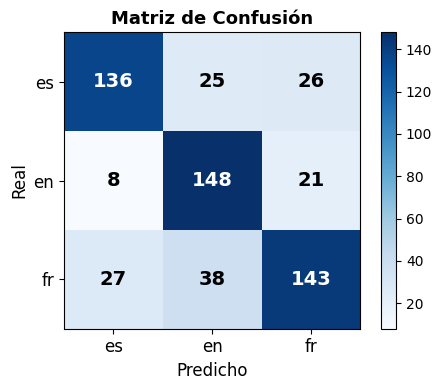

In [14]:
# --- Matriz de confusión ---

mc = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(mc, cmap='Blues')

ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(idiomas, fontsize=12)
ax.set_yticklabels(idiomas, fontsize=12)
ax.set_xlabel('Predicho', fontsize=12)
ax.set_ylabel('Real',     fontsize=12)
ax.set_title('Matriz de Confusión', fontsize=13, fontweight='bold')

for i in range(3):
    for j in range(3):
        color = 'white' if mc[i, j] > mc.max() / 2 else 'black'
        ax.text(j, i, str(mc[i, j]),
                ha='center', va='center',
                fontsize=14, fontweight='bold', color=color)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### ¿Qué es la curva de pérdida?

Es la pérdida graficada **época por época**. Si el entrenamiento va bien se ve así:

```
época   1 → pérdida 1.09  (red casi aleatoria, no sabe nada)
época  50 → pérdida 0.40  (empieza a aprender patrones)
época 200 → pérdida 0.08  (ya aprendió bien)
época 500 → pérdida 0.02  (convergió)
```

- Si la curva **no baja** → la red no está aprendiendo (arquitectura incorrecta o datos insuficientes)
- Si baja en train pero **no en test** → *overfitting* (memoriza en vez de generalizar)

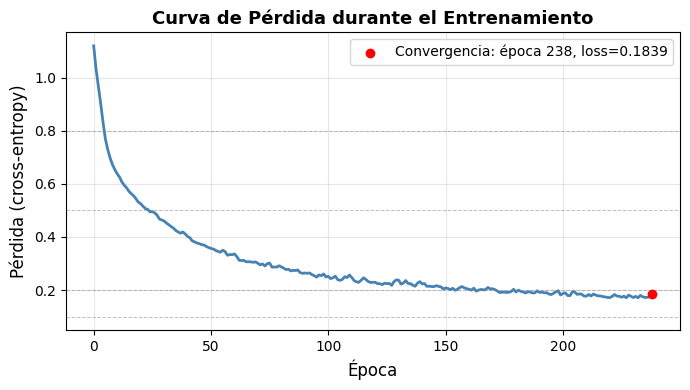

--- Lectura de la curva ---
  Época   1 → pérdida 1.1192  (red recién inicializada)
  Época  59 → pérdida 0.3333
  Época  119 → pérdida 0.2295
  Época 238 → pérdida 0.1839  (convergencia)


In [15]:
perdidas = red.loss_curve_

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(perdidas, color='steelblue', linewidth=2)

# marcamos el punto de convergencia
epoca_min   = len(perdidas) - 1
perdida_min = perdidas[-1]
ax.scatter(epoca_min, perdida_min, color='red', zorder=5,
           label=f'Convergencia: época {epoca_min}, loss={perdida_min:.4f}')

# líneas de referencia horizontales
for nivel in [0.8, 0.5, 0.2, 0.1]:
    ax.axhline(nivel, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)

ax.set_xlabel('Época', fontsize=12)
ax.set_ylabel('Pérdida (cross-entropy)', fontsize=12)
ax.set_title('Curva de Pérdida durante el Entrenamiento',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("--- Lectura de la curva ---")
n = len(perdidas)
print(f"  Época   1 → pérdida {perdidas[0]:.4f}  (red recién inicializada)")
print(f"  Época  {n//4} → pérdida {perdidas[n//4]:.4f}")
print(f"  Época  {n//2} → pérdida {perdidas[n//2]:.4f}")
print(f"  Época {n-1} → pérdida {perdidas[-1]:.4f}  (convergencia)")

---
## 6️ . Función de Predicción — Palabras OOV

### ¿Por qué el modelo puede predecir palabras OOV?

El modelo **nunca memoriza palabras completas**. Trabaja en tres niveles de abstracción:

**Nivel 1 — Trigramas**
La palabra `"ciberseguridad"` nunca fue vista, pero sus trigramas (`cib`, `iber`, `ber`, `uri`, `dad`) sí aparecen en palabras españolas del corpus.

**Nivel 2 — PCA**
Los 80 componentes representan *combinaciones de trigramas que co-ocurren* en cada idioma. Una palabra nueva se proyecta al mismo espacio por sus trigramas.

**Nivel 3 — Pesos de la red**
La red aprendió fronteras en ese espacio. No dice *"conozco esta palabra"*, sino *"este vector de 80 números se parece a los vectores del español"*.

```
"ciberseguridad"  →  trigramas conocidos del español
                  →  vector TF-IDF con esos pesos
                  →  PCA proyecta a zona 'española' del espacio
                  →  red dice ES con alta confianza ✓
```

In [16]:
# --- Pipeline completito de predicción ---
def predecir_idioma(palabra):
    # ordensito: palabra - trigramas - vector TF-IDF - PCA - Red - idioma

    # Paso 1: extraer trigramas de la palabra nueva
    tgs   = trigramas_de(palabra)
    total = len(tgs)

    # Paso 2: contar trigramas que están en el vocabulario entrenado
    # (si un trigrama es nuevo, simplemente no aporta — eso está bien)
    conteo = {}
    for tg in tgs:
        if tg in vocab:   # solo trigramas conocidos del entrenamiento
            conteo[tg] = conteo.get(tg, 0) + 1

    # Paso 3: construir vector TF-IDF del mismo tamaño que en entrenamiento
    vector = np.zeros(len(vocab))
    for tg, cnt in conteo.items():
        j         = vocab[tg]
        vector[j] = (cnt / total) * idf[tg]   # TF × IDF

    # Paso 4: proyectar con el PCA ya entrenado
    vector_pca = pca.transform(vector.reshape(1, -1))   # shape (1, 80)

    # Paso 5: predecir con la red
    probs     = red.predict_proba(vector_pca)[0]        # [P(es), P(en), P(fr)]
    idx_pred  = int(np.argmax(probs))
    idioma    = idiomas[idx_pred]
    confianza = probs[idx_pred]

    return idioma, confianza, probs


# --- Reporte con barritas ---
def reportar(palabra):
    idioma, confianza, probs = predecir_idioma(palabra)

    print(f"\n  Palabra  : '{palabra}'")
    print(f"  Predicho : {idioma.upper()}  (confianza {confianza*100:.1f}%)")
    for i in range(len(idiomas)):
        barra = '█' * int(probs[i] * 20)
        print(f"    {idiomas[i]} {probs[i]*100:5.1f}%  {barra}")

In [17]:
# --- Pruebas con palabras CONOCIDAS (dentro del corpus) ---
print("-----------------------------------------------" )
print("PALABRAS CONOCIDAS (vistas en entrenamiento)")
print("-----------------------------------------------" )

conocidas = [
    ("inteligencia", "es"),
    ("aprendizaje",  "es"),
    ("intelligence", "en"),
    ("computer",     "en"),
    ("apprentissage","fr"),
    ("ordinateur",   "fr"),
]

aciertos = 0
for palabra, esperado in conocidas:
    idioma, confianza, probs = predecir_idioma(palabra)
    ok = ":D ✓" if idioma == esperado else "✗ )"
    print(f"  {ok} '{palabra}' → {idioma.upper()} "
          f"(esperado: {esperado.upper()}, confianza: {confianza*100:.1f}%)")
    if idioma == esperado:
        aciertos += 1

print(f"\n  Aciertos en conocidas: {aciertos}/{len(conocidas)}")

-----------------------------------------------
PALABRAS CONOCIDAS (vistas en entrenamiento)
-----------------------------------------------
  :D ✓ 'inteligencia' → ES (esperado: ES, confianza: 97.3%)
  :D ✓ 'aprendizaje' → ES (esperado: ES, confianza: 82.6%)
  :D ✓ 'intelligence' → EN (esperado: EN, confianza: 76.7%)
  :D ✓ 'computer' → EN (esperado: EN, confianza: 85.4%)
  :D ✓ 'apprentissage' → FR (esperado: FR, confianza: 70.3%)
  :D ✓ 'ordinateur' → FR (esperado: FR, confianza: 99.8%)

  Aciertos en conocidas: 6/6


In [18]:
# --- Pruebas con palabras OOV (nunca vistas en entrenamiento) ---
print("-----------------------------------------------" )
print("PALABRAS OOV (nunca vistas en entrenamiento)")
print("-----------------------------------------------" )

oov = [
    # Español
    ("ciberseguridad",  "es"),
    ("neurociencia",    "es"),
    ("sostenibilidad",  "es"),
    # Inglés
    ("cybersecurity",   "en"),
    ("neuroscience",    "en"),   # ⚠ cognado perfecto EN=FR, límite teórico del modelo
    ("sustainability",  "en"),
    # Francés
    ("cybersécurité",   "fr"),
    ("neurosciences",   "fr"),
    ("durabilité",      "fr"),
]

aciertos_oov = 0
for palabra, esperado in oov:
    idioma, confianza, probs = predecir_idioma(palabra)
    ok = "✓" if idioma == esperado else "✗"
    print(f"  {ok} '{palabra}' → {idioma.upper()} "
          f"(esperado: {esperado.upper()}, confianza: {confianza*100:.1f}%)")
    if idioma == esperado:
        aciertos_oov += 1

print(f"\n  Aciertos en OOV: {aciertos_oov}/{len(oov)}")

-----------------------------------------------
PALABRAS OOV (nunca vistas en entrenamiento)
-----------------------------------------------
  ✓ 'ciberseguridad' → ES (esperado: ES, confianza: 92.6%)
  ✓ 'neurociencia' → ES (esperado: ES, confianza: 97.4%)
  ✓ 'sostenibilidad' → ES (esperado: ES, confianza: 99.9%)
  ✓ 'cybersecurity' → EN (esperado: EN, confianza: 89.1%)
  ✓ 'neuroscience' → EN (esperado: EN, confianza: 75.7%)
  ✓ 'sustainability' → EN (esperado: EN, confianza: 99.8%)
  ✓ 'cybersécurité' → FR (esperado: FR, confianza: 68.8%)
  ✗ 'neurosciences' → EN (esperado: FR, confianza: 68.6%)
  ✓ 'durabilité' → FR (esperado: FR, confianza: 100.0%)

  Aciertos en OOV: 8/9


### Ojito sobre neuroscience

neuroscience es un **cognado perfecto**: la palabra es ortográficamente idéntica en inglés y francés. Mismos trigramas, mismo vector TF-IDF, mismo punto en el espacio PCA. Es imposible distinguirlos sin contexto de oración.

Esto no es un fallo del modelo — es el **límite teórico** de nuestro clasificador por palabra aislada. Para resolverlo ocupamos contexto: "neuroscience research" → EN, "la neuroscience moderne" → FR.

In [19]:
# --- Demo visual con reporte de barras ---
print("=" * 52)
print("DEMO — reporte visual detallado")
print("=" * 52)

demos = ["ciberseguridad", "cybersecurity", "cybersécurité",
         "neurociencia",   "neuroscience",  "neurosciences"]

for p in demos:
    reportar(p)

DEMO — reporte visual detallado

  Palabra  : 'ciberseguridad'
  Predicho : ES  (confianza 92.6%)
    es  92.6%  ██████████████████
    en   5.2%  █
    fr   2.2%  

  Palabra  : 'cybersecurity'
  Predicho : EN  (confianza 89.1%)
    es   0.0%  
    en  89.1%  █████████████████
    fr  10.9%  ██

  Palabra  : 'cybersécurité'
  Predicho : FR  (confianza 68.8%)
    es   0.0%  
    en  31.2%  ██████
    fr  68.8%  █████████████

  Palabra  : 'neurociencia'
  Predicho : ES  (confianza 97.4%)
    es  97.4%  ███████████████████
    en   2.4%  
    fr   0.2%  

  Palabra  : 'neuroscience'
  Predicho : EN  (confianza 75.7%)
    es   0.9%  
    en  75.7%  ███████████████
    fr  23.4%  ████

  Palabra  : 'neurosciences'
  Predicho : EN  (confianza 68.6%)
    es  23.9%  ████
    en  68.6%  █████████████
    fr   7.5%  █


In [20]:
# --- Pa jugar ---
print("----------------------------------------")
print("Escribe la palabra a probar:")

"""
while True:
    entrada = input("\n  Palabra (o 'salir'): ").strip()
    if entrada.lower() == 'salir':
        print("  Saliendo...")
        break
    if len(entrada) < 3:
        print("  Mínimo 3 caracteres para extraer trigramas.")
        continue
    reportar(entrada)
"""

----------------------------------------
Escribe la palabra a probar:


'\nwhile True:\n    entrada = input("\n  Palabra (o \'salir\'): ").strip()\n    if entrada.lower() == \'salir\':\n        print("  Saliendo...")\n        break\n    if len(entrada) < 3:\n        print("  Mínimo 3 caracteres para extraer trigramas.")\n        continue\n    reportar(entrada)\n'

---
## B) A través de Ngramas, entrene un modelo para predecir la palabra siguiente. No aplique One-hot, aplique reducción de dimensionalidad.

### Ngramas de palabras

In [43]:
def ngramas_palabras(lista_tokens, n=3):
    lista = [None] * len(lista_tokens)
    contador = 0

    limite = len(lista_tokens) - n + 1 #se calculan cuantos ngramas pueden haber
    
    if limite > 0:
        for i in range(limite):
            ngram = tuple(lista_tokens[i: i+n]) #se hace una tupla de i hasta i+3
            lista[contador] = ngram
            contador += 1
    ngramas_finales = lista[0:contador]
    
    return ngramas_finales

In [44]:
trigramas_es = ngramas_palabras(tokens_es, n=3)
trigramas_en = ngramas_palabras(tokens_en, n=3)
trigramas_fr = ngramas_palabras(tokens_fr, n=3)
print(trigramas_es[:5])

[('la', 'inteligencia', 'artificial'), ('inteligencia', 'artificial', 'es'), ('artificial', 'es', 'una'), ('es', 'una', 'de'), ('una', 'de', 'las')]


In [45]:
total_trigramas_es = len(trigramas_es)
total_trigramas_en = len(trigramas_en)
total_trigramas_fr = len(trigramas_fr)
print(f'Total de trigramas de espanol: {total_trigramas_es}')
print(f'Total de trigramas de ingles: {total_trigramas_en}')
print(f'Total de trigramas de frances: {total_trigramas_fr}')

Total de trigramas de espanol: 857
Total de trigramas de ingles: 808
Total de trigramas de frances: 960


Se asignan las variables para cada documento

In [49]:
def separar_variable(trigramas):
    total_trigramas = len(trigramas)
    X_text = [None] * total_trigramas
    y_text = [None] * total_trigramas

    for i in range(total_trigramas):
        ngram = trigramas[i]
        contexto = [ngram[0], ngram[1]]
        
        objetivo = ngram[2]                 
        
        X_text[i] = contexto
        y_text[i] = objetivo
        
    return X_text, y_text

In [50]:
X_es, y_es = separar_variable(trigramas_es)
X_en, y_en = separar_variable(trigramas_en)
X_fr, y_fr = separar_variable(trigramas_fr)

corpus

In [51]:
X_total = X_es + X_en + X_fr 
y_total = y_es + y_en + y_fr
print(X_total[:5])
print(y_total[:5])

[['la', 'inteligencia'], ['inteligencia', 'artificial'], ['artificial', 'es'], ['es', 'una'], ['una', 'de']]
['artificial', 'es', 'una', 'de', 'las']


### Vectorización

In [52]:
#TF IDF
import numpy as np

def TF_IDF_matriz(corpus):
    vocabulario_set = set()
    for doc in corpus:
        for pal in doc:
            vocabulario_set.add(pal)
            
    vocabulario = list(vocabulario_set)
    num_doc_corpus = len(corpus)
    num_palabras_vocab = len(vocabulario)

    matriz_tfidf = np.zeros((num_doc_corpus, num_palabras_vocab))

    idfs = np.zeros(num_palabras_vocab) #calculo de IDF
    for j in range(num_palabras_vocab):
        palabra = vocabulario[j]
        num_doc_con_palabra = 0

        for i in range(num_doc_corpus): #se calcula en cuantos docs aparece la palabra
            if palabra in corpus[i]:  
                num_doc_con_palabra += 1

        if num_doc_con_palabra > 0: #evitar la division entre cero
            idfs[j] = np.log(num_doc_corpus / num_doc_con_palabra)
        else:
            idfs[j] = 0

    for i in range(num_doc_corpus): #calcular TF
        num_palabras_doc = len(corpus[i])
        
        if num_palabras_doc > 0:
            for j in range(num_palabras_vocab):
                palabra = vocabulario[j]
                
                contador = 0
                for pal in corpus[i]: #cuantas veces se repite la palabra j en el doc i
                    if pal == palabra:
                        contador += 1
                        
                tf = contador / num_palabras_doc 
                matriz_tfidf[i][j] = tf * idfs[j] #TF-IDF

    return matriz_tfidf, vocabulario

In [53]:
matriz_tfidf, vocabulario = TF_IDF_matriz(X_total)
print(matriz_tfidf)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [55]:
print(vocabulario[:10])

['detectar', 'systems', 'consist', 'solutions', 'cotidianos', 'simulated', 'infrastructure', 'beginnings', 'relâche', 'elle']


### PCA

### Predicción siguiente palabra